In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls '/content/drive/MyDrive/nlp_assignment_sentimentdata'

test_preprocessed.csv  train_preprocessed.csv


In [ ]:
import pandas as pd

train_path = '/content/drive/MyDrive/nlp_assignment_sentimentdata/train_preprocessed.csv'
test_path = '/content/drive/MyDrive/nlp_assignment_sentimentdata/test_preprocessed.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.head())
print(test_df.head())

                                               Tweet   Sentiment  \
0  @atRachelGilmore Wow...you must not know the d...  Strong_Neg   
1  @JacquiDelaney @brianlilley Police told Public...  Strong_Pos   
2  please take note on the people who were postin...  Strong_Pos   
3  âSlash The Tires, Arrest The Driversâ: Har...    Mild_Neg   
4  @RayanKReal @thevivafrei @JustinTrudeau that l...  Strong_Pos   

                                         Clean_Tweet  Label  
0  Wow...you must not know the difference between...      3  
1  Police told Public Safety Minister Marco Mendi...      4  
2  please take note on the people who were postin...      4  
3  âSlash The Tires, Arrest The Driversâ Harvard ...      0  
4  that looks like a mostly peaceful protest, not...      4  
                                               Tweet   Sentiment  \
0  The #RCMP started sharing names of individuals...    Mild_Pos   
1  Whoa, Canada: Police criminalize food, fuel do...  Strong_Pos   
2  Just closed 

In [ ]:
def tokenize(text):
    return re.findall(r'\b\w+\b', str(text).lower())

In [ ]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove.6B

def load_glove(file_path):
    embeddings = {}
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = list(map(float, parts[1:]))
            embeddings[word] = vector
    return embeddings

glove_embeddings = load_glove('glove.6B/glove.6B.100d.txt')
print(f"GloVe vectors loaded: {len(glove_embeddings)}")

GloVe vectors loaded: 400000


In [ ]:
import re
import numpy as np

# Step 1: Safe tokenization
def tokenize(text):
    return re.findall(r'\b\w+\b', str(text).lower())

# Step 2: Average GloVe vector for one tweet
def avg_glove_vector(text, embeddings, dim=100):
    tokens = tokenize(text)
    vectors = [embeddings[word] for word in tokens if word in embeddings]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

# Step 3: Clean missing values (if any)
train_df['Clean_Tweet'] = train_df['Clean_Tweet'].fillna('')
test_df['Clean_Tweet'] = test_df['Clean_Tweet'].fillna('')

# Step 4: Generate feature arrays
X_train_glove = np.array([avg_glove_vector(t, glove_embeddings) for t in train_df['Clean_Tweet']])
X_test_glove = np.array([avg_glove_vector(t, glove_embeddings) for t in test_df['Clean_Tweet']])

print("Embedding generation complete")
print("X_train_glove shape:", X_train_glove.shape)
print("X_test_glove shape:", X_test_glove.shape)

Embedding generation complete
X_train_glove shape: (406198, 100)
X_test_glove shape: (45134, 100)


In [ ]:
# Make sure these are defined before using them
y_train = train_df['Label']
y_test = test_df['Label']

Evaluation Metrics:
Accuracy: 0.6007
F1 Score: 0.5159
AUC Score: 0.7717


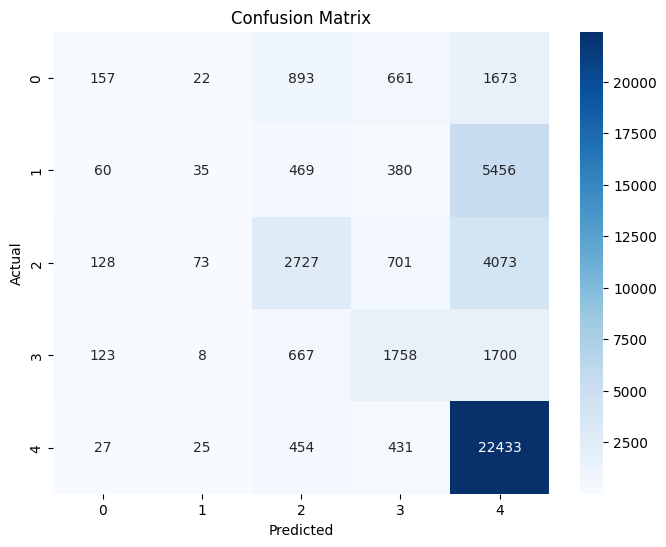

In [ ]:
# Step 1: Make sure labels are defined
y_train = train_df['Label']
y_test = test_df['Label']

# Step 2: Use subset for faster training
train_subset = train_df.sample(n=20000, random_state=42)
X_train_sub = np.array([avg_glove_vector(t, glove_embeddings) for t in train_subset['Clean_Tweet']])
y_train_sub = train_subset['Label']

# Step 3: Train SVM
from sklearn.svm import SVC
svm = SVC(kernel='linear', C=1, probability=True)
svm.fit(X_train_sub, y_train_sub)

# Step 4: Predict
y_pred = svm.predict(X_test_glove)
y_proba = svm.predict_proba(X_test_glove)

# Step 5: Evaluate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_test is defined here too
y_test = test_df['Label']

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')

print("Evaluation Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
!pip install --upgrade --force-reinstall gensim==4.3.2 scipy==1.10.1 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 9.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cvxpy 1.6.5 requires scipy>=1.11.0, but you have scipy 1.10.1 which is incompatible.
jax 0.5.2 requires scipy>=1.11.1, but you have scipy 1.10.1 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.5.1 requires scipy>=1.11.1, but you have scipy 1.10.1 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.10.1 which is incompatible.
xarray-einstats 0.9.0 requires scipy>=1.11, but you have scipy 1.10.1 which is incompatible.
scikit-image 0.25.2 requires scipy>

In [ ]:
import os
os.kill(os.getpid(), 9)  # Forces Colab to restart

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.simple.vec

from gensim.models import KeyedVectors

fasttext_embeddings = KeyedVectors.load_word2vec_format('wiki.simple.vec', binary=False)
print(f"FastText vectors loaded: {len(fasttext_embeddings)}")

FastText vectors loaded: 111051


In [ ]:
import re
import numpy as np

def tokenize(text):
    return re.findall(r'\b\w+\b', str(text).lower())

def avg_fasttext_vector(text, embeddings, dim=300):
    tokens = tokenize(text)
    vectors = [embeddings[word] for word in tokens if word in embeddings]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

In [ ]:
import pandas as pd

# Load your preprocessed train and test CSV files
train_path = '/content/drive/MyDrive/nlp_assignment_sentimentdata/train_preprocessed.csv'
test_path = '/content/drive/MyDrive/nlp_assignment_sentimentdata/test_preprocessed.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Then run your embedding averaging code
X_train_fasttext = np.array([avg_fasttext_vector(t, fasttext_embeddings) for t in train_df['Clean_Tweet']])
X_test_fasttext = np.array([avg_fasttext_vector(t, fasttext_embeddings) for t in test_df['Clean_Tweet']])


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the labels loaded as well
y_train = train_df['Label']  # Replace 'Label' with your actual label column name
y_test = test_df['Label']

# Train the SVM classifier
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train_fasttext, y_train)

# Predict on test data
y_pred = svm.predict(X_test_fasttext)
y_proba = svm.predict_proba(X_test_fasttext)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

# Binarize labels for AUC if multiclass
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)
if len(classes) == 2:  # binary classification
    auc = roc_auc_score(y_test, y_proba[:, 1])
else:  # multiclass
    auc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')

print(f'Accuracy: {acc:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'AUC: {auc:.4f}')

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()